In [1]:
import os, sys
from pathlib import Path

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from nre.preprocess import preprocess_df
from nre.network_connectivity import ConnectivityUnit, cic_conn_param_specs, ton_iot_conn_param_specs
from nre.analyze_nf_dataset import nre_classification, flow_based_classification
from nre.classification_tools import plot_roc_curves

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [14]:

# CIC-IDS-2017
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'  # 'Monday-WorkingHours.pcap_ISCX.csv' #  Wednesday-workingHours.pcap_ISCX.csv
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# NF-ToN-IoT
file_addr = r'..\..\NF-ToN-IoT\NF-ToN-IoT-v3-small.csv'
#file_addr = r'..\..\NF-ToN-IoT\NF-ToN-IoT-v3.csv'

# Definitions
date_col = 'FLOW_START_MILLISECONDS' # 'FLOW_START_MILLISECONDS' # ' Timestamp'
label_col = 'Label' # 'Label' # ' Label'
benign_label = '0'  # '0' # 'BENIGN'
src_id_col = 'IPV4_SRC_ADDR' # ' Source IP'
dst_id_col = 'IPV4_DST_ADDR' # ' Total Backward Packets'
src_feature_col = 'OUT_PKTS' # ' Total Fwd Packets'
dst_feature_col = 'IN_PKTS' # ' Total Backward Packets'
conn_param = 'NPS'
conn_param_specs = ton_iot_conn_param_specs
feat_cols = ('OUT_PKTS', 'IN_PKTS')

In [3]:
#df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df_iot = pd.read_csv(file_addr, sep=',', encoding='utf-8')

#df = preprocess_df(df_cic, date_col=' Timestamp')
df_whole = preprocess_df(df_iot, date_col=date_col)

print(df_whole.shape)

(507190, 55)


In [4]:
df_whole.columns

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

In [5]:
df_whole

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.32,41315,192.168.1.169,10010,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
338134,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.248,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338133,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.247,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338132,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.246,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338131,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,35309,192.168.35.158,80,6,7,40,1,...,0,0,0,0,0,0,0,0,1,scanning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169056,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,37324,192.168.1.186,1098,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
169055,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.30,0,192.168.35.143,0,1,81,28,1,...,0,0,0,0,0,0,0,0,0,Benign
169054,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,41220,192.168.1.46,13782,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
169052,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.32,37024,192.168.1.193,60020,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign


In [6]:
np.unique(df_whole[label_col].values, return_counts= True)

(array([0, 1], dtype=object), array([311240, 195950], dtype=int64))

# Network Scope (Optional)

## CIC-IDS-2017 

In [6]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle)
len(entity_names)

13

In [3]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle: #105
    subnet_names = pickle.load(handle) 
len(subnet_names)

141

## NF-ToN-IoT

In [7]:
with open(r'saves/ton_iot_small_freq_1000.pickle', 'rb') as handle: #105
    subnet_names = pickle.load(handle) 
entity_names = subnet_names.copy()
len(subnet_names)

15

# Network State Inference Experiment

## Train - Test Split
Use the same split (seed) in validation section

In [8]:
seed = 138
test_size = 0.33

ind_co = int(df_whole.shape[0] * (1 - test_size))
df_train, df_test = df_whole.iloc[:ind_co, :], df_whole.iloc[ind_co:, :]

Conditioning number:  9.670948102424662e+18 
Determinant of F^T*F:  -3.093864060126532e-100


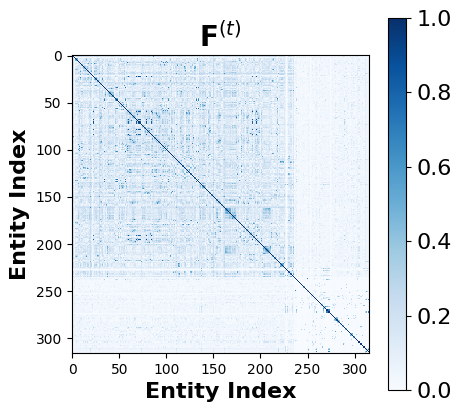

<Figure size 640x480 with 0 Axes>

In [10]:
from nre.network_connectivity import ton_iot_conn_param_specs

#kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 
#          'conn_param':conn_param, window_type= 'time', sync_window_size= 20, time_scale= 'sec'} # 20s

kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 'conn_param':conn_param,
          'window_type':'conn', 'conn_size':500}



cu = ConnectivityUnit(conn_param_specs=ton_iot_conn_param_specs)
cu.read_flows(df_train, **kwargs) 
cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

In [17]:


#models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Trees': DecisionTreeClassifier(),
#          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}
models = {'Decision Trees': DecisionTreeClassifier(), #'Logistic Regression': LogisticRegression(),
          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}


#okwargs = {'labelling_opt': 'attacks first', 'conn_param': 'NPR', 'feat_cols': (' Total Fwd Packets', ' Total Backward Packets')}

okwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 'window_type':'conn', 
          'entity_names': entity_names, 'label_col':label_col, 'conn_param_specs':ton_iot_conn_param_specs, 'benign_label': benign_label,
           'seed':30, 'labelling_opt': 'majority'}

nre_curves = {}
#df_nre = nre_classification(df_train, models, test_df=df_test, entity_names=subnet_names, t_graph=90,
#                            conn_param=conn_param, sync_window_size=1.2, verbose=True, roc_curves=nre_curves, seed=30)
df_nre = nre_classification(df_train, models, test_df=df_test, n_graph=8000, conn_size=100, forget_factor= 0.5, relief_factor= 0.6,
                            roc_curves=nre_curves, conn_param=conn_param, verbose=True, **okwargs)
print(df_nre)

Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1970-01-01 00:25:56.030000 (80, 15)
Current time and samples shape:  1

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
import importlib
import nre.classification_tools

importlib.reload(nre.classification_tools)
from nre.classification_tools import *

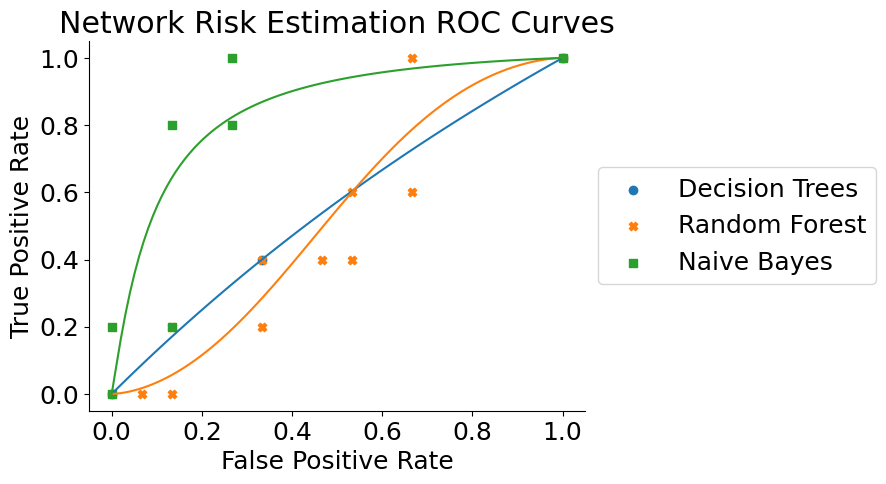

In [20]:
fig1 = plot_roc_curves(nre_curves, title='Network Risk Estimation ROC Curves')

In [20]:
import importlib
import src.classification_tools

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import *

In [21]:
len(entity_names), len(subnet_names)

(13, 141)

In [63]:
names = subnet_names
idx = df[src_feature_col].isin(names) & df[dst_feature_col].isin(names)
df_filt = df[idx].copy()

In [64]:
df[df[label_col] != benign_label]

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
68410,192.168.10.8-205.174.165.73-53966-444-6,192.168.10.8,53966,205.174.165.73,444,6,2017-06-07 02:19:00,2030,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
66383,192.168.10.8-205.174.165.73-53966-444-6,192.168.10.8,53966,205.174.165.73,444,6,2017-06-07 02:19:00,42664070,5,6,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
72581,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:28:00,119991834,5523,5525,...,20,997842.0,831471.3076,1585781.0,409903.0,8143987.5,1821773.648,9432176.0,6855799.0,Infiltration
75039,192.168.10.8-205.174.165.73-54131-444-6,192.168.10.8,54131,205.174.165.73,444,6,2017-06-07 02:30:00,119974830,3398,3398,...,20,824363.0,0.0,824363.0,824363.0,9785751.0,0.0,9785751.0,9785751.0,Infiltration
73090,192.168.10.8-205.174.165.73-54122-444-6,192.168.10.8,54122,205.174.165.73,444,6,2017-06-07 02:30:00,5005212,15,15,...,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
73634,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:30:00,119973135,4376,4374,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
78192,192.168.10.8-205.174.165.73-54131-444-6,192.168.10.8,54131,205.174.165.73,444,6,2017-06-07 02:32:00,118573317,3733,3732,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
77580,192.168.10.8-205.174.165.73-54573-444-6,192.168.10.8,54573,205.174.165.73,444,6,2017-06-07 02:32:00,78233714,48,52,...,20,2024843.8,3093999.209,7461188.0,3051.0,13600000.0,10200000.0,29500000.0,5662979.0,Infiltration
77445,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:32:00,119993844,3813,3811,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infiltration
82330,192.168.10.8-205.174.165.73-54119-444-6,192.168.10.8,54119,205.174.165.73,444,6,2017-06-07 02:34:00,119992821,2252,2250,...,20,34300000.0,11400000.0,42400000.0,26200000.0,19400000.0,15500000.0,30300000.0,8400626.0,Infiltration


In [65]:
df_filt[df_filt[label_col] != benign_label]

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label


In [47]:
feat_cols = ('Active Mean', ' Flow Duration', 'Flow Bytes/s', ' Fwd Header Length', ' Bwd Header Length',
                     'Idle Mean', ' act_data_pkt_fwd', ' Total Fwd Packets', ' Total Backward Packets', ' Fwd IAT Mean',
                     ' Bwd IAT Mean', ' Fwd Packet Length Mean', ' Bwd Packet Length Mean', ' Source Port',
                     ' Destination Port', ' Protocol', ' Bwd IAT Mean', ' Fwd IAT Mean')
feat_cols = (' Flow Duration', )#(' Total Fwd Packets', ' Total Backward Packets')

feat_cols = ('OUT_PKTS', 'IN_PKTS')
okwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 'window_type':'conn',
          'label_col':label_col, 'conn_param_specs':ton_iot_conn_param_specs, 'benign_label': benign_label, 
          'labelling_opt': 'majority'}



models = {'Decision Trees': DecisionTreeClassifier(), #'Logistic Regression': LogisticRegression(),
          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}

flow_based_curves = {}
#df_flow_based = flow_based_classification(df_train, models, test_df=df_test, t_graph=180, entity_names= entity_names,# sub_net_size=.5,# entity_names=subnet_names,
#                                          feat_cols = feat_cols, roc_curves=flow_based_curves, seed=138) #32
df_flow_based = flow_based_classification(df_train, models, test_df=df_test, n_graph=8000, entity_names= entity_names,# sub_net_size=.5,# entity_names=subnet_names,
                                          roc_curves=flow_based_curves, seed=138, feat_cols=feat_cols, conn_param=conn_param, verbose=True,
                                          **okwargs) #32
print(df_flow_based)

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                Accuracy  Precision  Recall  Balanced Accuracy   f1
Decision Trees      0.75        0.0     0.0                0.5  0.0
Random Forest       0.75        0.0     0.0                0.5  0.0
Naive Bayes         0.75        0.0     0.0                0.5  0.0


C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\nre\analyze_nf_dataset.py:327: UserWarning: Reported results are not fully representative since thresholding is not implemented for the flow_based_classification function directly. Use the roc_curves parameters to gauge the performance instead.
  warnings.warn('Reported results are not fully representative s

In [35]:
flow_based_curves

{'Decision Trees': (array([0.        , 0.13333333, 0.2       , 1.        ]),
  array([0. , 0. , 0.2, 1. ])),
 'Random Forest': (array([0.        , 0.06666667, 0.13333333, 0.33333333, 1.        ]),
  array([0. , 0. , 0. , 0.2, 1. ])),
 'Naive Bayes': (array([0., 1.]), array([0., 1.]))}

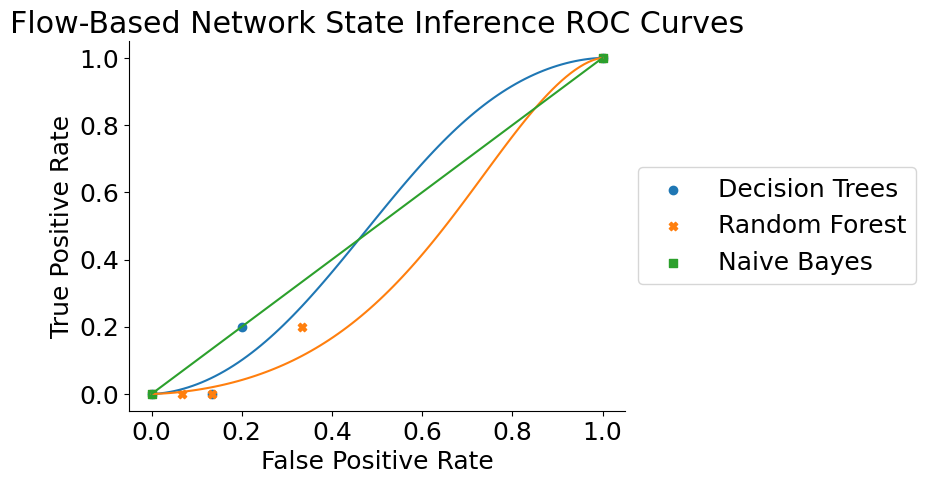

In [36]:
fig2 = plot_roc_curves(flow_based_curves, title='Flow-Based Network State Inference ROC Curves')

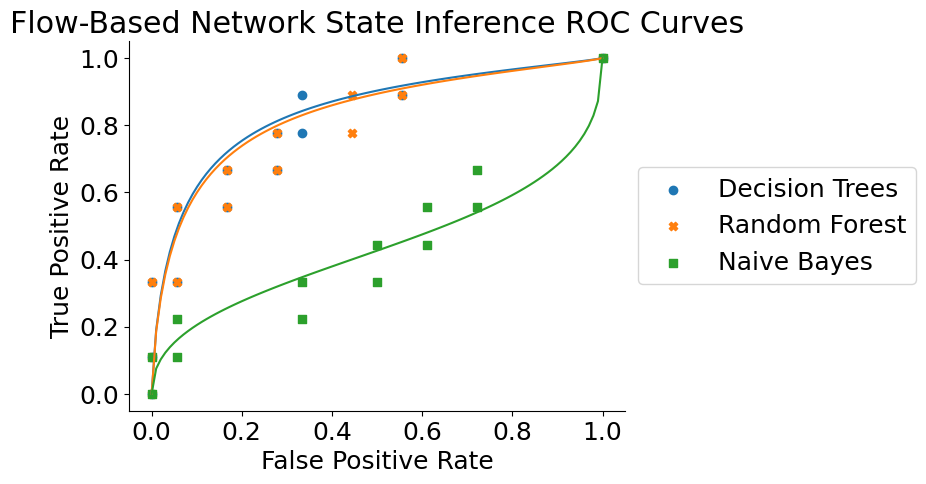

In [55]:
fig2 = plot_roc_curves(flow_based_curves, title='Flow-Based Network State Inference ROC Curves')

In [52]:
import importlib
import nre.analyze_nf_dataset

importlib.reload(nre.analyze_nf_dataset)
from nre.analyze_nf_dataset import *

In [53]:
from nre.analyze_nf_dataset import compare_among_conn_params

conn_params = ['NPS', 'NPR'] # 

#all_df, roc_curves = compare_among_conn_params(df_train, entity_names_nre=subnet_names, entity_names_fb=entity_names,# sub_net_size=.9,
#                                               control=True,t_graph=180, sync_window_size=1.2, best_op_point=True, seed=138, #32
#                                               forget_factor=0.5, relief_factor=0.2)#, conn_params=conn_params, models=models)

all_df, roc_curves = compare_among_conn_params(df_train, entity_names_nre=subnet_names, entity_names_fb=entity_names, 
                                               control=True, n_graph=8000, conn_size=100, best_op_point=True, seed=138, #32
                                               forget_factor=0.5, relief_factor=0.6, **okwargs)

All features:  ['DST_TO_SRC_AVG_THROUGHPUT', 'DST_TO_SRC_IAT_AVG', 'FLOW_DURATION_MILLISECONDS', 'IN_BYTES', 'IN_PKTS', 'L4_DST_PORT', 'L4_SRC_PORT', 'OUT_BYTES', 'OUT_PKTS', 'PROTOCOL', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'SRC_TO_DST_IAT_AVG']


C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
  0%|           

AssertionError: Feature value frequencies must be provided for mode aggregation method

In [6]:
import pickle

with open(r'saves\sweep_thursday_web_180_1_2_control_all_two.pickle', 'wb') as handle:
    pickle.dump(all_df, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
with open(r'saves\sweep_thursday_web_180_1_2_control_all.pickle', 'rb') as handle:
    all_df = pickle.load(handle)

In [12]:
all_df 

,Balanced Accuracy,Connection Parameter,Classifier,Method
0,0.703401,Number of Packets Sent,Decision Trees,FBNSI
1,0.707116,Number of Packets Sent,Random Forest,FBNSI
2,0.563957,Number of Packets Sent,Naive Bayes,FBNSI
3,0.421393,Number of Packets Sent,Decision Trees,NRE
4,0.772764,Number of Packets Sent,Random Forest,NRE
...,...,...,...,...
112,0.849329,Idle Time,Random Forest,NRE
113,0.454825,Idle Time,Naive Bayes,NRE
114,0.915470,Idle Time,Decision Trees,FBNSI Control
115,0.847990,Idle Time,Random Forest,FBNSI Control


..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


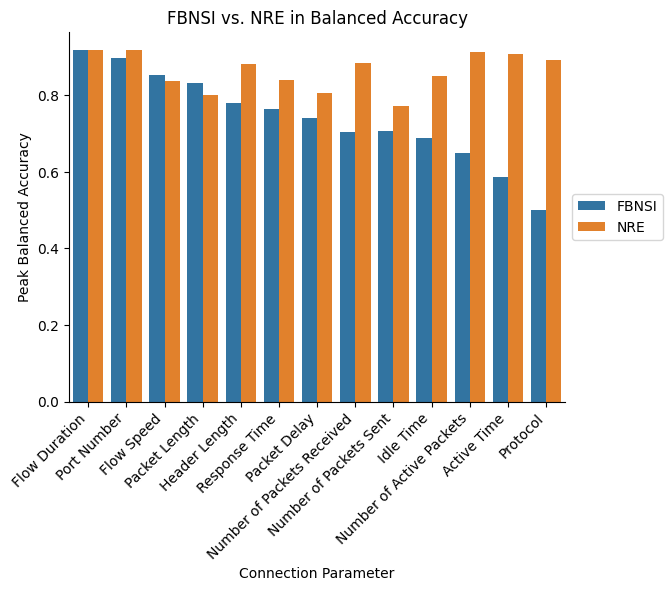

In [13]:
from src.analyze_cic_ids import plot_perf_comparison

fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True, hue_order=['FBNSI', 'NRE'],
                          order=['Flow Duration', 'Port Number' ,'Flow Speed', 'Packet Length', 'Header Length', 'Response Time', 'Packet Delay',
                                 'Number of Packets Received', 'Number of Packets Sent', 'Idle Time', 'Number of Active Packets',
                                 'Active Time', 'Protocol'])#, 'FBNSI Control'])
print(file_addr)

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


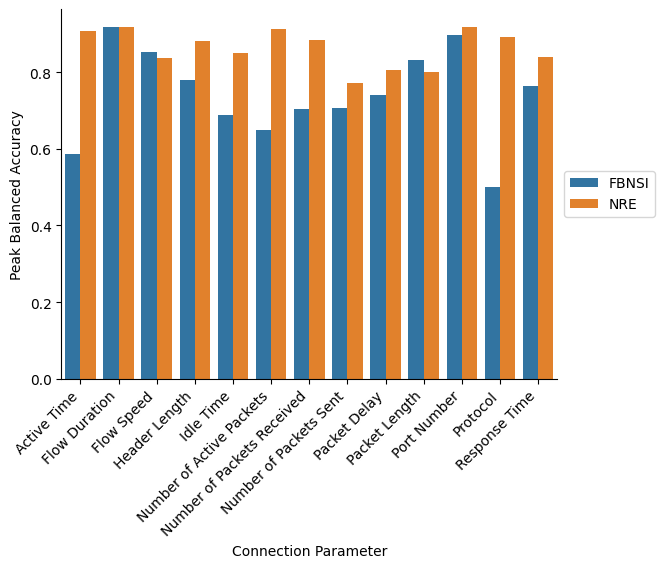

In [8]:
from src.analyze_cic_ids import plot_perf_comparison

fig = plot_perf_comparison(all_df, title='', peak_only=True, hue_order=['FBNSI', 'NRE'])
print(file_addr)

In [32]:
roc_curves

{'Decision Trees': (array([0., 1.]), array([nan, nan])),
 'Random Forest': (array([0., 1.]), array([nan, nan])),
 'Naive Bayes': (array([0., 1.]), array([nan, nan]))}

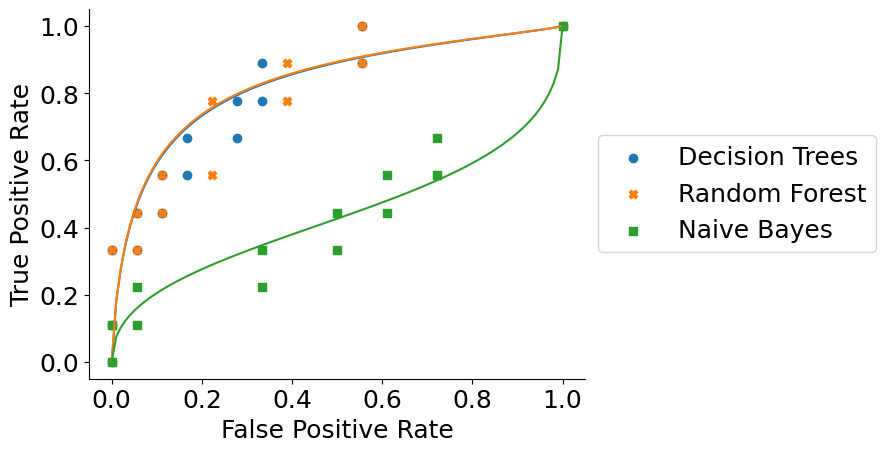

In [58]:
fig3 = plot_roc_curves(roc_curves, title='')

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


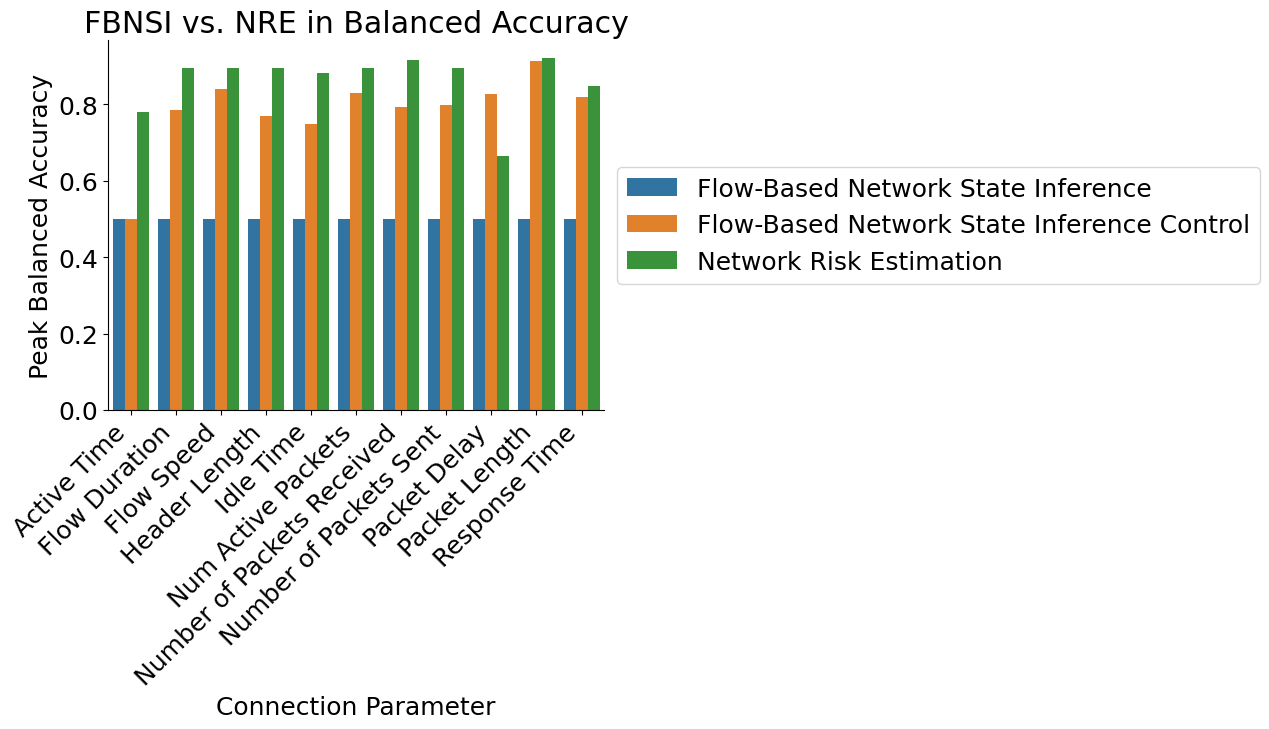

In [150]:
fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True)
print(file_addr)

..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


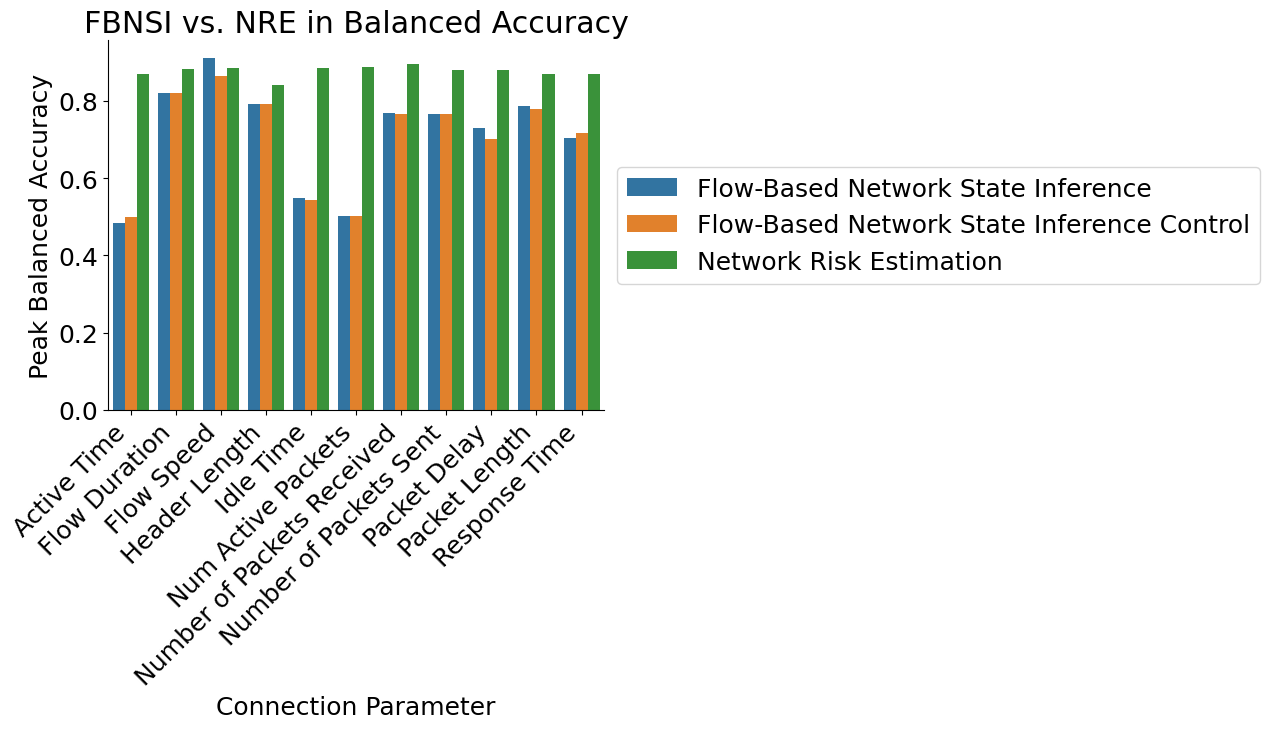

In [130]:
fig = plot_perf_comparison(all_df, title='FBNSI vs. NRE in Balanced Accuracy',  peak_only=True)
print(file_addr)

# Miscellaneous

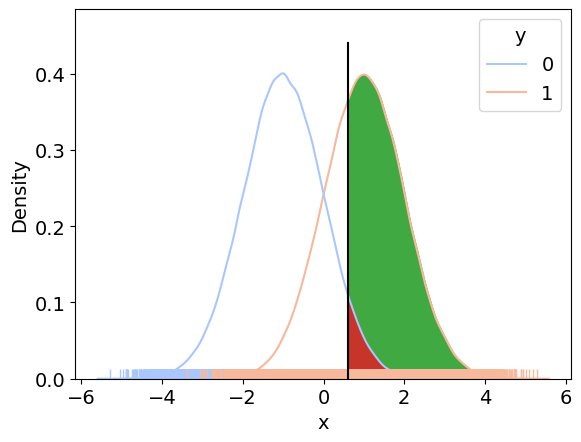

In [187]:
from scipy.stats import norm

from_sample = True
N = 100_000
plot_op, plot_thr = True, True
t = 0.6
plt.rcParams.update({'font.size': 14})

if not from_sample:
    xs1 = np.linspace(-4.5, 4.5, 2000)
    xs0 = xs1
    pdf0 = norm.pdf(xs0, -1, 1)
    pdf1 = norm.pdf(xs1, 1, 1)
    
    plt.plot(xs0, pdf0, label='0', color="tab:blue")
    plt.plot(xs1, pdf1, label='1', color="tab:red")
    plt.xlabel('x')
    plt.legend()
    ax = plt.gca()
else:
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    
    sns.kdeplot(data=df, x="x", hue="y", palette="coolwarm", common_norm=False)
    sns.rugplot(data=df, x="x", hue="y", palette="coolwarm")#, clip_on=False, height=-.02,)
    ax = plt.gca()
    li1, li0 = ax.lines[0], ax.lines[1]
    xs0  = li0.get_data()[0]
    pdf0 = li0.get_data()[1]
    xs1  = li1.get_data()[0]
    pdf1 = li1.get_data()[1]

if plot_thr:
    ax.plot([t, t], [0, ax.get_ylim()[1]], 'k')
    
    if plot_op:
        # True Positive
        ind = xs1 > t
        plt.fill_between(xs1[ind], pdf1[ind], 0, color='tab:green', alpha=0.9)
        
        # False Positives
        ind = xs0 > t
        plt.fill_between(xs0[ind], pdf0[ind], color='tab:red', alpha=0.9)

        



Text(0, 0.5, 'TPR')

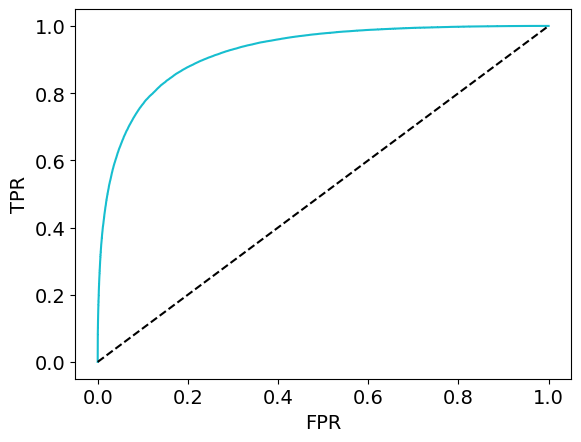

In [189]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
ax.plot(fpr, tpr, color='tab:cyan')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')
plt.xlabel('FPR')
plt.ylabel('TPR')

Text(0, 0.5, 'TPR')

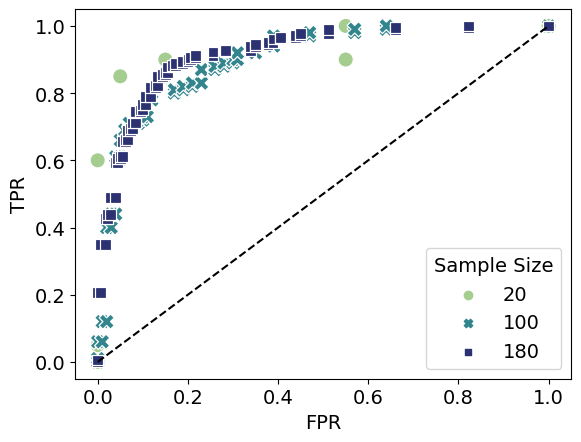

In [186]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
all_df = pd.DataFrame()
for N in np.arange(20, 200, 80):
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
    
    temp_df = pd.DataFrame({'FPR': fpr, 'TPR':tpr, 'Sample Size': N})
    all_df = pd.concat((all_df, temp_df))
    #ax.scatter(fpr, tpr, 'o', label=str(N))
    
sns.scatterplot(data=all_df, x='FPR', y='TPR', hue='Sample Size', style='Sample Size', s=120, ax=ax, palette='crest')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')    
plt.xlabel('FPR')
plt.ylabel('TPR')
#plt.legend()

In [161]:
np.arange(20, 30, 2)

array([20, 22, 24, 26, 28])